Importing All necessary Libraries to analyze the data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("retail_demand_dataset.csv")

In [4]:
df.head()

,Date,Year,Month,Month_Name,Product,Store,Price,Competitor_Price,Discount_Percent,Marketing_Spend,Inventory_Level,Customer_Rating,Season,Demand
0,2022-01-01,2022,1,January,Laptop,Reliance Smart,44348.24,43743.59,4,69589.77,773,4.376166,Winter,773
1,2022-01-01,2022,1,January,Headphones,Spencer's,11008.59,11142.77,29,38682.24,770,3.401812,Winter,770
2,2022-01-01,2022,1,January,Smartwatch,More Supermarket,17690.70,18308.28,22,8365.57,1342,4.658020,Winter,396
3,2022-01-01,2022,1,January,Smartwatch,DMart,7739.33,7687.37,31,8566.47,979,3.662461,Winter,400
4,2022-01-01,2022,1,January,Tablet,More Supermarket,26754.99,26034.86,16,53178.40,591,4.555681,Winter,591


In [5]:
df.columns

Index(['Date', 'Year', 'Month', 'Month_Name', 'Product', 'Store', 'Price',
       'Competitor_Price', 'Discount_Percent', 'Marketing_Spend',
       'Inventory_Level', 'Customer_Rating', 'Season', 'Demand'],
      dtype='str')

In [6]:
df.shape

(50000, 14)

In [7]:
df.nunique()

Date                 1461
Year                    4
Month                  12
Month_Name             12
Product                 5
Store                   6
Price               49837
Competitor_Price    49855
Discount_Percent       41
Marketing_Spend     49851
Inventory_Level      1500
Customer_Rating     47650
Season                  4
Demand               1839
dtype: int64

In [8]:
df.isnull().sum()

Date                0
Year                0
Month               0
Month_Name          0
Product             0
Store               0
Price               0
Competitor_Price    0
Discount_Percent    0
Marketing_Spend     0
Inventory_Level     0
Customer_Rating     0
Season              0
Demand              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe(include =object)

C:\Users\USER\AppData\Local\Temp\ipykernel_26576\2308160983.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include =object)


,Date,Month_Name,Product,Store,Season
count,50000,50000,50000,50000,50000
unique,1461,12,5,6,4
top,2023-05-29,August,Smartwatch,DMart,Summer
freq,58,4347,10169,8422,12665


In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.quarter
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Day'] = df['Date'].dt.day
df['Day_Name'] = df['Date'].dt.day_name()
df['Day_of_Week'] = df['Date'].dt.dayofweek

In [12]:
season_map = {
    1: 'Winter', 2: 'Winter', 3: 'Spring', 
    4: 'Spring', 5: 'Spring', 6: 'Summer',
    7: 'Summer', 8: 'Summer',9: 'Autumn', 
    10: 'Autumn', 11: 'Autumn',12: 'Winter'
}

df['Season'] = df['Month'].map(season_map)

In [13]:
df.columns

Index(['Date', 'Year', 'Month', 'Month_Name', 'Product', 'Store', 'Price',
       'Competitor_Price', 'Discount_Percent', 'Marketing_Spend',
       'Inventory_Level', 'Customer_Rating', 'Season', 'Demand', 'Quarter',
       'Week', 'Day', 'Day_Name', 'Day_of_Week'],
      dtype='str')

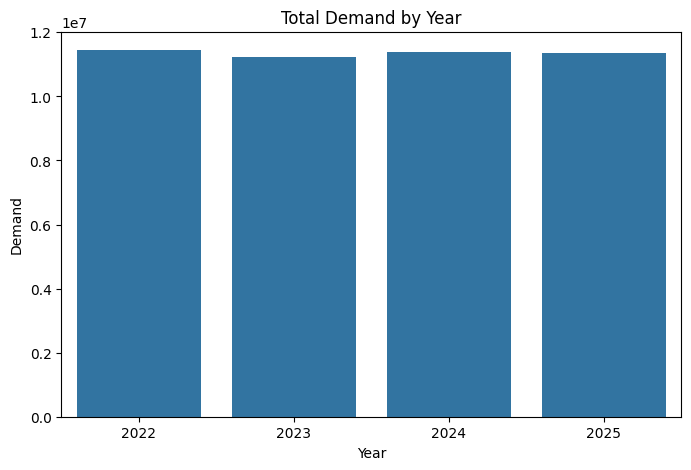

In [16]:
yearly_demand = (
    df.groupby('Year')['Demand']
      .sum()
      .sort_index()
)

yearly_demand
plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_demand.index,
    y=yearly_demand.values
)

plt.title("Total Demand by Year")
plt.xlabel("Year")
plt.ylabel("Demand")

plt.show()

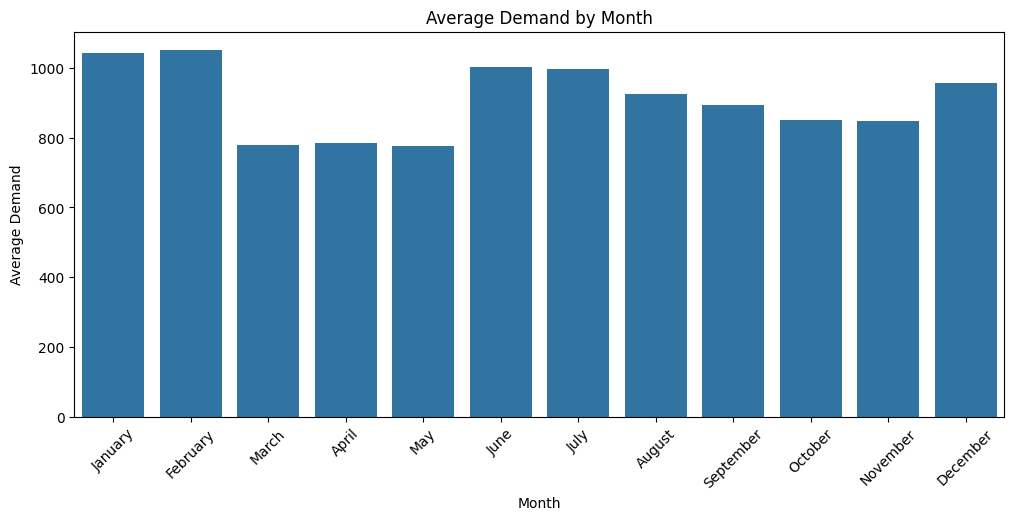

In [17]:
month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

month_demand = (
    df.groupby('Month_Name')['Demand']
      .mean()
      .reindex(month_order)
)

month_demand

plt.figure(figsize=(12,5))

sns.barplot(
    x=month_demand.index,
    y=month_demand.values
)

plt.xticks(rotation=45)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")

plt.show()

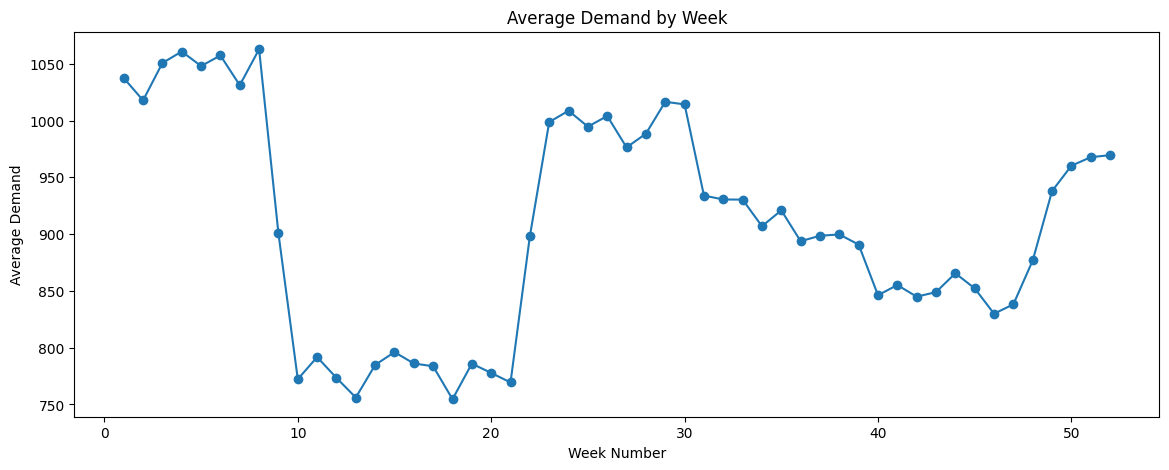

In [18]:
week_demand = (
    df.groupby('Week')['Demand']
      .mean()
)
plt.figure(figsize=(14,5))

plt.plot(
    week_demand.index,
    week_demand.values,
    marker='o'
)

plt.title("Average Demand by Week")
plt.xlabel("Week Number")
plt.ylabel("Average Demand")

plt.show()

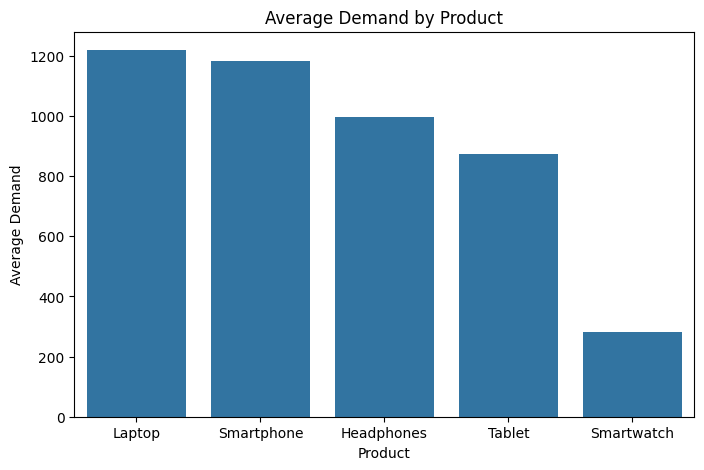

In [19]:
product_demand = (
    df.groupby('Product')['Demand']
      .mean()
      .sort_values(ascending=False)
)

product_demand
plt.figure(figsize=(8,5))

sns.barplot(
    x=product_demand.index,
    y=product_demand.values
)

plt.title("Average Demand by Product")
plt.xlabel("Product")
plt.ylabel("Average Demand")

plt.show()

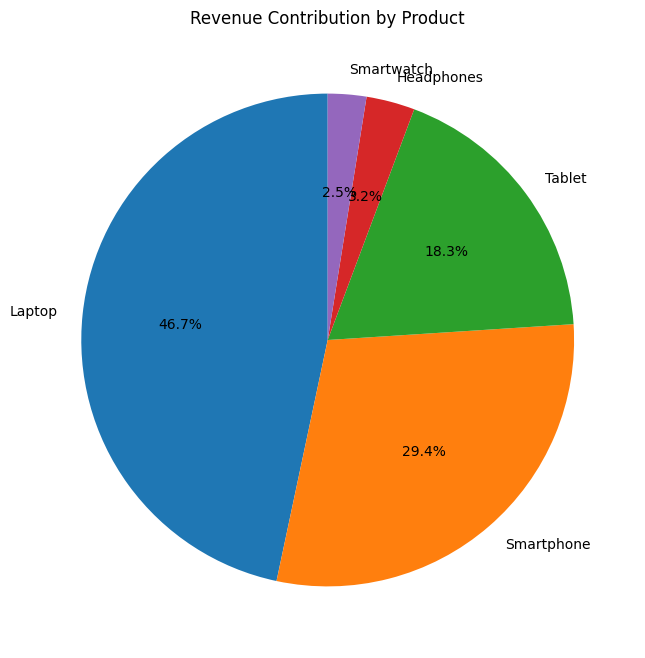

In [21]:
product_revenue = (
    (df['Price'] * df['Demand'])
    .groupby(df['Product'])
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    product_revenue,
    labels=product_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Revenue Contribution by Product")

plt.show()

KPIs

In [23]:
df['Revenue'] = df['Price'] * df['Demand']

df['Price_Difference'] = (
    df['Price'] - df['Competitor_Price']
)

df['Discount_Amount'] = (
    df['Price'] * df['Discount_Percent'] / 100
)

df['Estimated_Profit'] = (
    df['Revenue'] - df['Marketing_Spend']
)

df['Demand_Category'] = pd.qcut(
    df['Demand'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [31]:
# ==========================
# Business KPI Summary
# ==========================

total_revenue=df['Revenue'].sum()
total_demand=df['Demand'].sum()
avg_price=df['Price'].mean()
avg_comp_price =df['Competitor_Price'].mean()
avg_discount=df['Discount_Percent'].mean()
total_marketing=df['Marketing_Spend'].sum()
avg_rating=df['Customer_Rating'].mean()
avg_inventory=df['Inventory_Level'].mean()
estimated_profit=df['Estimated_Profit'].sum()
revenue_per_unit=total_revenue / total_demand

print("=" * 50)
print("BUSINESS KPI SUMMARY")
print("=" * 50)

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Demand: {total_demand:,.0f}")
print(f"Average Product Price: ${avg_price:.2f}")
print(f"Average Competitor Price: ${avg_comp_price:.2f}")
print(f"Average Discount (%): {avg_discount:.2f}%")
print(f"Total Marketing Spend: ${total_marketing:,.2f}")
print(f"Average Customer Rating: {avg_rating:.2f}")
print(f"Average Inventory Level: {avg_inventory:.2f}")
print(f"Estimated Profit: ${estimated_profit:,.2f}")
print(f"Revenue per Unit Demand: ${revenue_per_unit:.2f}")

print("=" * 50)

BUSINESS KPI SUMMARY
Total Revenue: $2,008,346,757,346.47
Total Demand: 45,404,422
Average Product Price: $38908.10
Average Competitor Price: $39406.39
Average Discount (%): 20.04%
Total Marketing Spend: $2,738,375,727.67
Average Customer Rating: 3.98
Average Inventory Level: 1250.62
Estimated Profit: $2,005,608,381,618.80
Revenue per Unit Demand: $44232.40


In [32]:
df.columns

Index(['Date', 'Year', 'Month', 'Month_Name', 'Product', 'Store', 'Price',
       'Competitor_Price', 'Discount_Percent', 'Marketing_Spend',
       'Inventory_Level', 'Customer_Rating', 'Season', 'Demand', 'Quarter',
       'Week', 'Day', 'Day_Name', 'Day_of_Week', 'Revenue', 'Price_Difference',
       'Discount_Amount', 'Estimated_Profit', 'Demand_Category'],
      dtype='str')

In [33]:
df.to_csv("demand_analysis_final.csv", index=False)